# Pairs Trading Strategy
 **Author**: Matthew Bradshaw
 **Date** : August 2026

## Overview

This project aims to implement a piars trading strategy on two oilo bond ETFs using 
**Engle-Granger cointegration test** and **static OLS regression** hedge ratios. 

## Methodology

**1. Data Acquisition** Load 1000 days of historical data from Yahoo Finance for our
two assets, combining close prices into a single data frame.

**2. Signal Definiton** Create the statistically verified trading signal as the foundation
for our strategy.

**3. Stretgy Performance** Backtest the strategy over the last 1000 days and assess its
performance based on Sharpe Rtaio, Maximum Drawdown and Win Rate.

In [33]:
#Load libraraies
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm 
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 22})
plt.rcParams["figure.figsize"] = (12,8)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


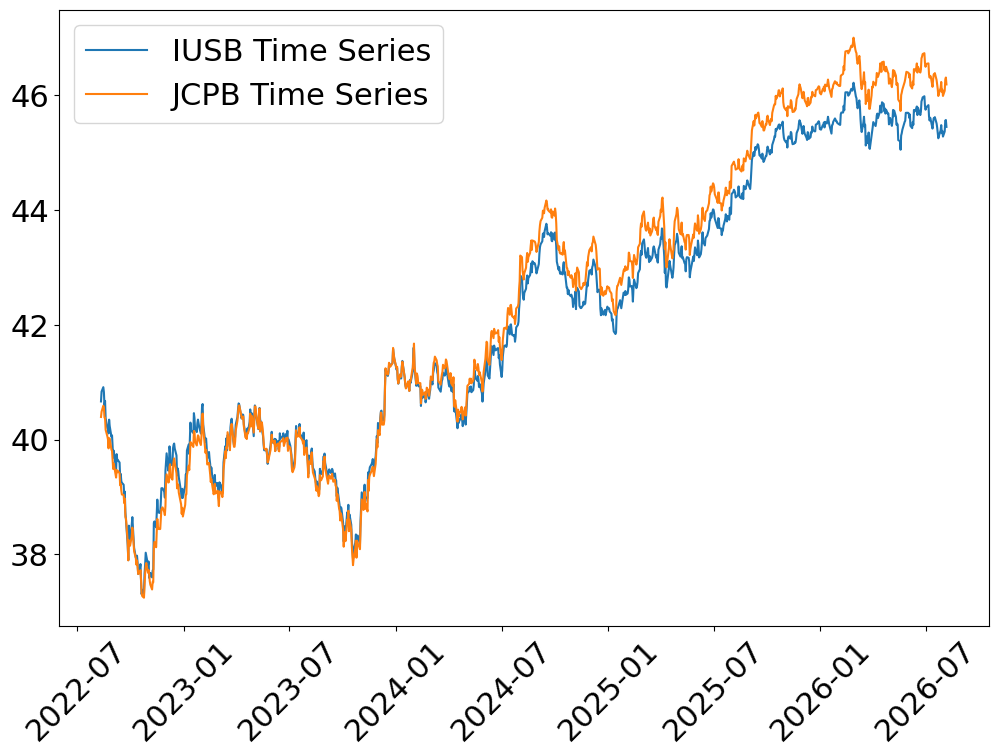

Hedge Ratio: 0.8852


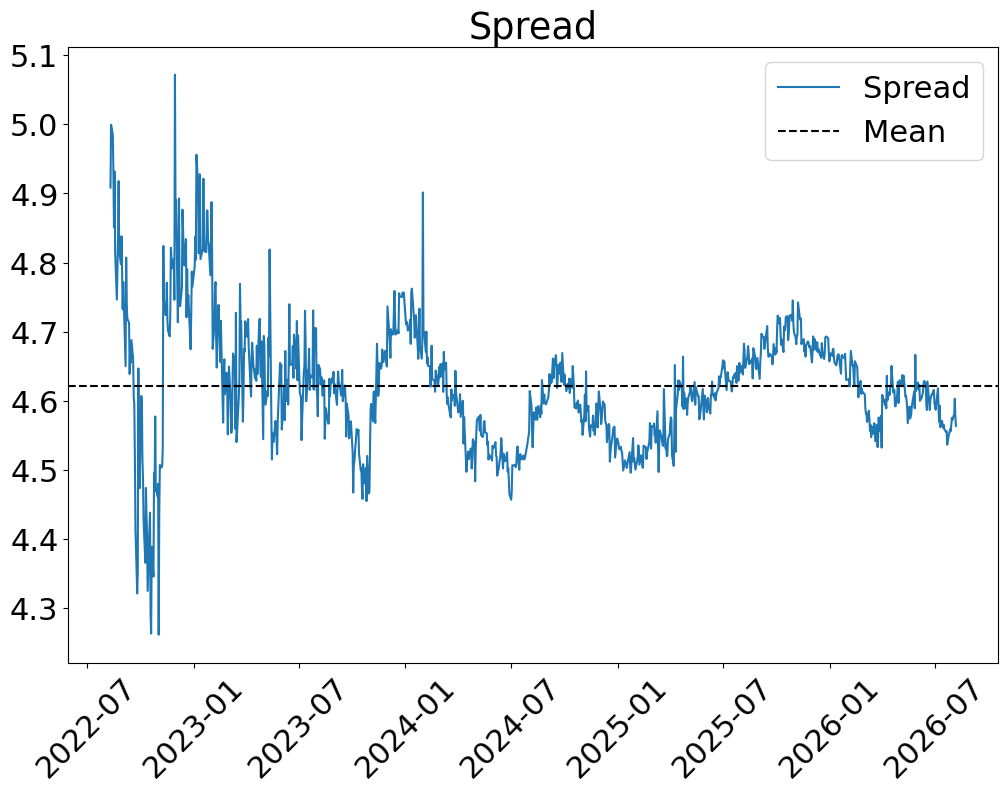

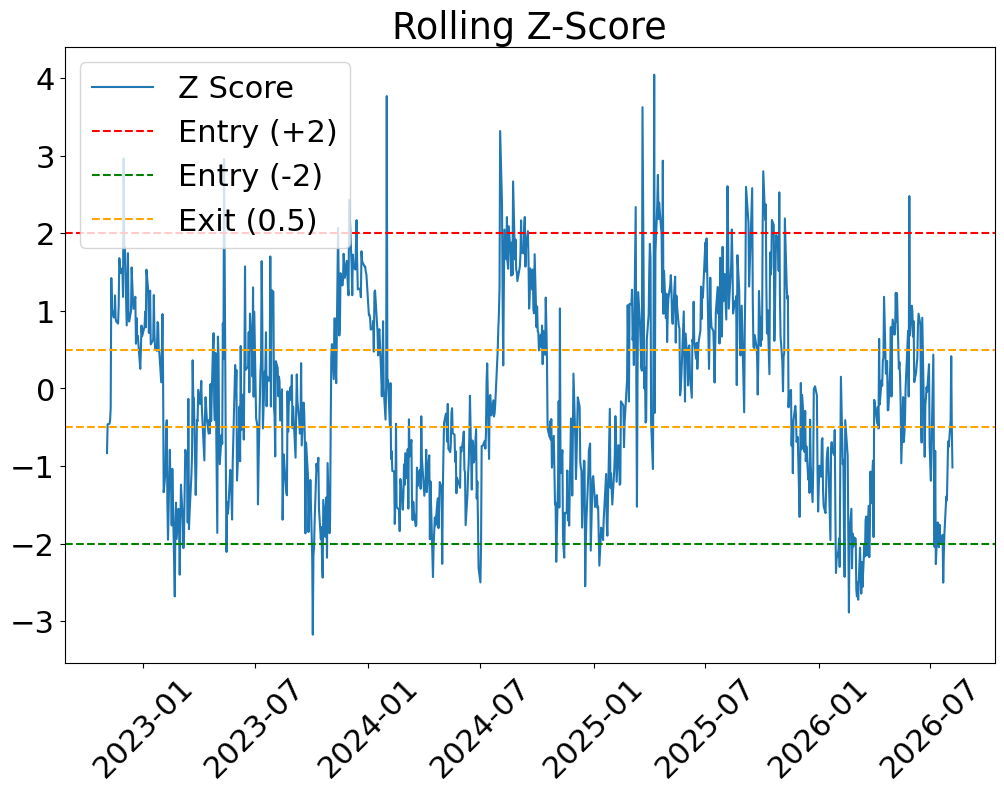

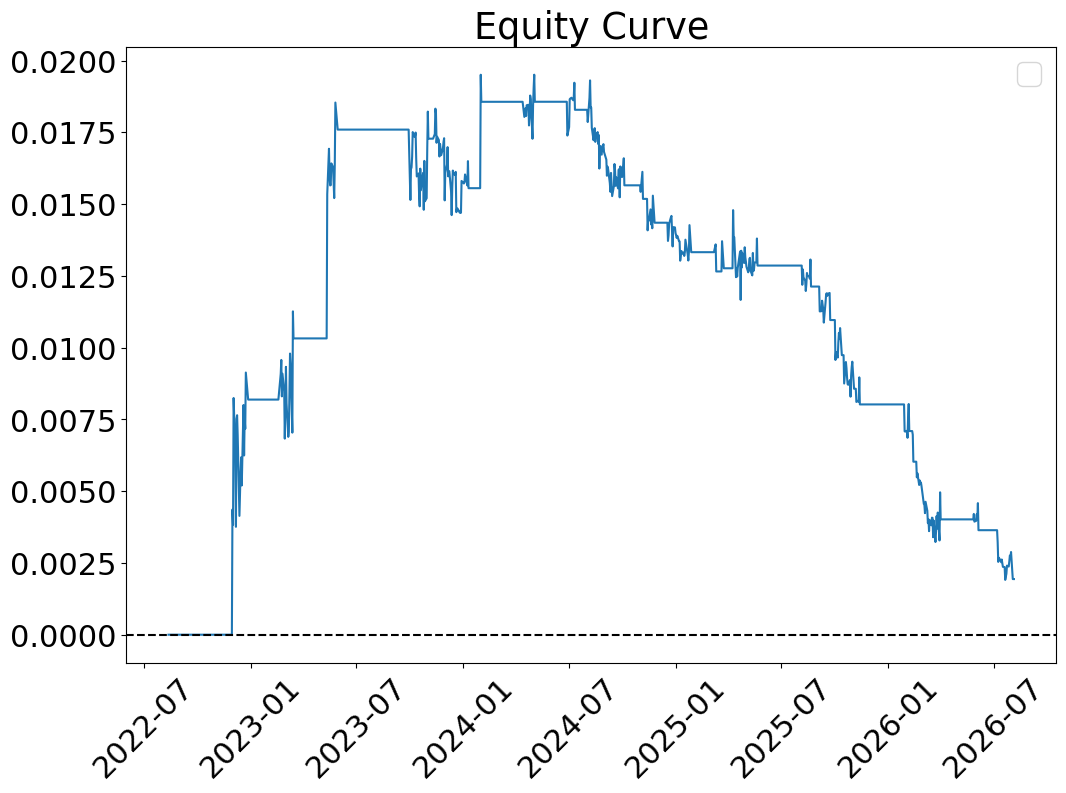

Sharpe Ratio =  0.06
Max Drawdown =  0.02
Win Rate =  49.18%
Summary from 01-01-2022 to 31-12-2023 | Total PnL =  0.02 | Total Trades = 10 | Losing Trades = 5 | Win Rate =  50.00%
Summary from 01-01-2024 to 06 -08-2026 | Total PnL = -0.01 | Total Trades = 46 | Losing Trades = 32 | Win Rate =  30.43%


Price,IUSB,JCPB,beta,spread,z_score,position,daily_pnl,net_pnl,trade_id
Date,,,,,,,,,
2022-08-11,40.665352,40.395214,0.885173,4.908602,NaN,0.0,NaN,NaN,0
2022-08-12,40.836868,40.486423,0.885173,4.999382,NaN,0.0,NaN,-0.000000,0
2022-08-15,40.914051,40.590103,0.885173,4.984790,NaN,0.0,-0.000000,-0.000000,0
2022-08-16,40.828289,40.552773,0.885173,4.932072,NaN,0.0,-0.000000,-0.000000,0
2022-08-17,40.596748,40.382763,0.885173,4.851020,NaN,0.0,-0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...
2026-07-31,45.281002,45.989002,0.885173,4.572782,-0.753013,1.0,-0.000092,0.000214,54
2026-08-03,45.369999,46.080002,0.885173,4.581228,-0.418725,0.0,0.000214,-0.000943,55
2026-08-04,45.560001,46.270000,0.885173,4.603049,0.414610,0.0,0.000000,-0.000000,55


In [34]:
TICKER1 = 'IUSB'
#iShares Core Universal USD Bond ETF

TICKER2 = 'JCPB'
#JPMorgan Core Plus Bond ETF

INTERVAL = '1d'

if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'
    
LOOKBACK = 1000
NOTIONAL = 10000 
TRADE_COST = 0.0005

#Import CHOLV data from Yahoo Finance
def get_data1(ticker = TICKER1, lookback = LOOKBACK, interval = INTERVAL):
    df = yf.download(ticker, interval = interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    if INTERVAL == '1d':
        df = df
    else:
        df = df.reset_index(drop = True)

    return df.iloc[-lookback:,:] 

def get_data2(ticker = TICKER2, lookback = LOOKBACK, interval = INTERVAL):
    
    df = yf.download(ticker, interval = interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    if INTERVAL == '1d':
        df = df
    else:
        df = df.reset_index(drop = True)

    return df.iloc[-lookback:,:] 
    
def load_data():
    #Loading data sets and combining the close prices into one df
    df1 = get_data1()
    df2 = get_data2()

    price_1 = df1[['Close']].rename(columns ={'Close' : TICKER1})
    price_2 = df2[['Close']].rename(columns ={'Close' : TICKER2})

    df = pd.concat([price_1, price_2], axis = 1).dropna()
    
    plt.plot(df)
    plt.legend([f'{TICKER1} Time Series', f'{TICKER2} Time Series'])
    plt.xticks(rotation = 45)
    plt.show()

    return df

def add_spread(df):
    price_1 = df[TICKER1]
    price_2 = df[TICKER2]

    sm.tsa.stattools.coint(price_1, price_2, "c", "aeg")
    # Results from AEG test show conintegration so the pair is valid

    X = sm.add_constant(price_2)
    model = sm.OLS(price_1, X).fit()
    beta = model.params[1]
    print('=' * 120)
    print(f'Hedge Ratio: {beta:.4f}')
    print('=' * 120)
    df['beta'] = beta
    
    
    spread = price_1 - beta * price_2
    df['spread'] = spread

    window = 60

    rolling_mean = spread.rolling(window).mean()
    rolling_std = spread.rolling(window).std()

    df['z_score'] = (spread - rolling_mean)/rolling_std

    plt.plot(spread, label='Spread')
    plt.axhline(spread.mean(), color = 'black', linestyle = '--', label = 'Mean')
    plt.title("Spread")
    plt.legend()
    plt.xticks(rotation = 45)
    plt.show()

    plt.plot(df['z_score'], label = "Z Score")
    plt.axhline(2, color = 'red', linestyle = '--', label = 'Entry (+2)')
    plt.axhline(-2, color = 'green', linestyle = '--', label = 'Entry (-2)')
    plt.axhline(0.5, color = 'orange', linestyle = '--', label = 'Exit (0.5)')
    plt.axhline(-0.5, color = 'orange', linestyle = '--')
    plt.title("Rolling Z-Score")
    plt.legend()
    plt.xticks(rotation = 45)
    plt.show();

    return df

def add_strategy(df):
    
    position = np.zeros(len(df['z_score']))
    z_score = df['z_score'].values

    for i in range(1, len(position)):
        position[i] = position[i-1]

        if z_score[i] > 2:
            position[i] = -1
    
        elif z_score[i] < -2:
            position[i] = 1
    
        elif abs(z_score[i]) < 0.5:
            position[i] = 0

    df['position'] = position
    
    return df

def test_strategy(df, notional = NOTIONAL, trade_cost = TRADE_COST):
    
    spread_returns = df['spread'].diff()
    position = df['position'].values
    beta = df['beta']
    beta_trimmed = beta[1:]

    price_1 = df[TICKER1]
    price_2 = df[TICKER2]

    position_changes = np.abs(np.diff(position, prepend = position[0]))
    position_changes_trimmed = position_changes[1:]


    price_1_trimmed = price_1.iloc[1:]
    price_2_trimmed = price_2.iloc[1:]
    position_trimmed = position[1:]

    shares_1 = notional / price_1_trimmed
    shares_2 = (notional * beta_trimmed) / price_2_trimmed
    
    daily_pnl = position_trimmed[:-1] * (shares_1.values[:-1] * price_1_trimmed.diff().values[1:] - shares_2.values[:-1] * price_2_trimmed.diff().values[1:]) 
    daily_pnl = daily_pnl / notional
    daily_pnl_series = pd.Series(daily_pnl, index = df.index[2:])
    df['daily_pnl'] = daily_pnl_series

    transaction_costs = position_changes_trimmed[:-1] * trade_cost * (shares_1.values[:-1] * price_1_trimmed[:-1] + shares_2.values[:-1] * price_2_trimmed[:-1]) 
    transaction_costs = transaction_costs / notional

    net_pnl = daily_pnl - transaction_costs
    df['net_pnl'] = net_pnl
    cum_net_pnl = np.cumsum(net_pnl)

    
    plt.plot(cum_net_pnl)
    plt.title("Equity Curve")
    plt.axhline(0, linestyle ='--', color = 'black')
    plt.xlabel = ("Trading Days")
    plt.ylabel = ("Cumulative Profit & Loss (Spread Units)")
    plt.xticks(rotation = 45)
    plt.legend()
    plt.show();

    daily_std = net_pnl.std()
    daily_mean = net_pnl.mean()

    sharpe_ratio = (daily_mean / daily_std) * np.sqrt(252)
    print('=' * 120)
    print(f'Sharpe Ratio = {sharpe_ratio : .2f}')

    max_pnl = np.maximum.accumulate(cum_net_pnl)

    max_drawdown = max(max_pnl - cum_net_pnl)
    print(f'Max Drawdown = {max_drawdown : .2f}')

    total_trades = net_pnl[net_pnl != 0]
    n_trades = len(total_trades)
    win_rate = (total_trades > 0 ).sum() / n_trades
    print(f'Win Rate = {win_rate : .2%}')
    print('=' * 120)

    trade_id = np.zeros(len(position), dtype = int)
    current_id = 0
    for i in range(1, len(position)):
        if position[i] != position[i-1]:
            current_id += 1
        trade_id[i] = current_id

    df['trade_id'] = pd.Series(trade_id, index = df.index)
                   
    def summarize_period(df, start, end, pnl_col = 'net_pnl'):
        period = df.loc[start:end]
        total_pnl = period[pnl_col].sum()
        trade_pnls = period.groupby('trade_id')[pnl_col].sum()
        trade_pnls = trade_pnls[trade_pnls != 0]
        n_trades = len(trade_pnls)
        losing_trades = (trade_pnls < 0).sum()
        win_rate = (trade_pnls > 0).sum() / n_trades if n_trades > 0 else float('nan')
        return total_pnl, n_trades, losing_trades, win_rate
 
    period_1_sum = summarize_period(df, '2022-01-01', '2023-12-31')
    period_2_sum = summarize_period(df, '2024-01-01', '2026-08-06')
 
    print('=' * 120)
    print(f'Summary from 01-01-2022 to 31-12-2023 | Total PnL = {period_1_sum[0]: .2f} | '
          f'Total Trades = {period_1_sum[1]} | Losing Trades = {period_1_sum[2]} | Win Rate = {period_1_sum[3]: .2%}')
    print(f'Summary from 01-01-2024 to 06 -08-2026 | Total PnL = {period_2_sum[0]: .2f} | '
          f'Total Trades = {period_2_sum[1]} | Losing Trades = {period_2_sum[2]} | Win Rate = {period_2_sum[3]: .2%}')
    print('=' * 120)


    return df

def main():
    df = load_data()
    df = add_spread(df)
    df = add_strategy(df)
    df = test_strategy(df)
    return df

df = main()
df

## Interpretation
Overall the strategy yields a **Sharpe Ratio** of **0.06**, **Max Darwdown** of **0.02** and a **Win Rate** of **49.18%**. When we inspect the periods from 
2022 - 2023 and 
2024 - Present, we can see that this strategy performed better in the former period ratherthan the latter (notably there were significantly more trades in 
the latter period). The results I've come upon are indicative of the shift in regime in the bond market as it entered a period of lower volatility after 
the rate hikes from 2024 onward, so the strategy begins to signal off of minor noise rather statistically significant trading edge. This issue provides me 
with the motivation to adopt a dyanmic hedge ratio to adapt the stratgey to suit speriods of lower volatility

